## Imports and data loading

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import optuna
import yaml
import os
from models.architectures import (
    LSTMModel, LSTMAttentionModel, CNNLSTMModel, TransformerModel, build_model
)

repo_root = os.path.abspath('../')
with open(os.path.join(repo_root, 'config.yaml')) as f:
    cfg = yaml.safe_load(f)

processed_dir = os.path.join(repo_root, cfg['silder']['results']['processed'])
model_dir     = os.path.join(repo_root, cfg['paths']['model_dir'])
output_prefix = 'Silder_mixed_jrf_cop_leg'   # prefix for weights and Optuna study names

train_data = np.load(os.path.join(processed_dir, f'{output_prefix}_train_data.npz'))
val_data   = np.load(os.path.join(processed_dir, f'{output_prefix}_val_data.npz'))
test_data  = np.load(os.path.join(processed_dir, f'{output_prefix}_test_data.npz'),
                     allow_pickle=True)

X_train, y_train = train_data['X_train'], train_data['y_train']
X_val,   y_val   = val_data['X_val'],     val_data['y_val']
X_test,  y_test  = test_data['X_test'],   test_data['y_test']

INPUT_KEYS  = cfg['signals']['inputs']
OUTPUT_KEYS = [str(k) for k in test_data['output_keys']]

N_INPUTS  = len(INPUT_KEYS)
N_OUTPUTS = len(OUTPUT_KEYS)

MUSCLE_KEYS = [k for k in OUTPUT_KEYS if not k.startswith(('knee', 'ankle'))]
JOINT_KEYS  = [k for k in OUTPUT_KEYS if k.startswith(('knee', 'ankle'))]

print(f'Inputs  ({N_INPUTS}):  {INPUT_KEYS}')
print(f'Outputs ({N_OUTPUTS}): {OUTPUT_KEYS}')

assert X_train.shape[2] == N_INPUTS,  f'Expected {N_INPUTS} inputs,  got {X_train.shape[2]}'
assert y_train.shape[2] == N_OUTPUTS, f'Expected {N_OUTPUTS} outputs, got {y_train.shape[2]}'

SEQ_LEN = X_train.shape[1]
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

Inputs  (6):  ['grf_x', 'grf_y', 'grf_z', 'cop_x', 'cop_y', 'cop_z']
Outputs (44): ['addbrev', 'addlong', 'addmagDist', 'addmagIsch', 'addmagMid', 'addmagProx', 'bflh', 'bfsh', 'edl', 'ehl', 'fdl', 'fhl', 'gaslat', 'gasmed', 'glmax1', 'glmax2', 'glmax3', 'glmed1', 'glmed2', 'glmed3', 'glmin1', 'glmin2', 'glmin3', 'grac', 'iliacus', 'perbrev', 'perlong', 'psoas', 'recfem', 'semimem', 'semiten', 'soleus', 'tibant', 'tibpost', 'vasint', 'vaslat', 'vasmed', 'achilles', 'knee_fx', 'knee_fy', 'knee_fz', 'ankle_fx', 'ankle_fy', 'ankle_fz']
X_train: (872, 100, 6)  y_train: (872, 100, 44)
X_val:   (153, 100, 6)    y_val:   (153, 100, 44)
X_test:  (90, 100, 6)   y_test:  (90, 100, 44)


## Quick data visualization

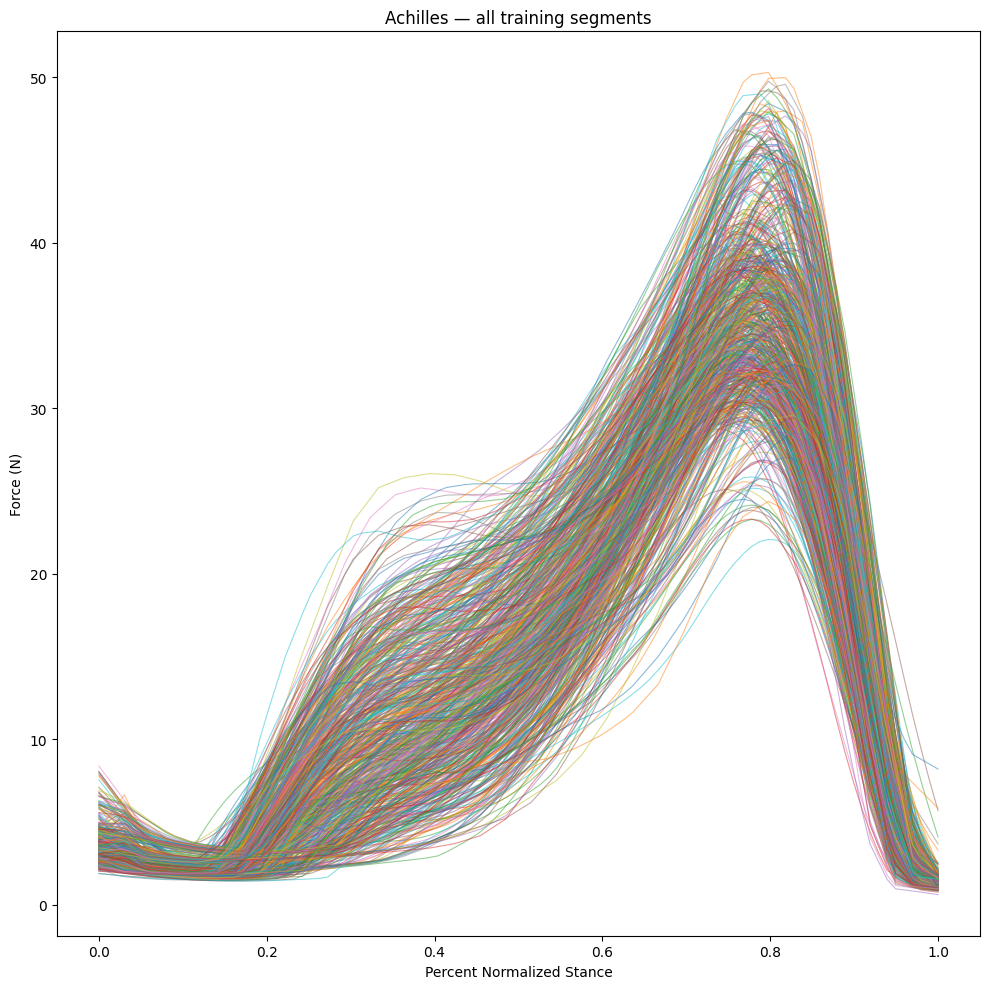

In [11]:
perc_stance  = np.linspace(0, 1, SEQ_LEN)
achilles_idx = OUTPUT_KEYS.index('achilles')
fig, ax = plt.subplots(figsize=(10, 10))
for i in range(len(y_train)):
    ax.plot(perc_stance, y_train[i, :, achilles_idx], linewidth=0.8, alpha=0.5)
ax.set_title('Achilles — all training segments')
ax.set_xlabel('Percent Normalized Stance')
ax.set_ylabel('Force (N)')
plt.tight_layout()
plt.show()

## Device setup and tensor construction

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)

Device: cuda


## Generic training loop

In [14]:
def train_eval(model, train_dataset, val_dataset,
               learning_rate, batch_size, regularization,
               grad_clip=0.0, num_epochs=500, patience=10):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate,
                           weight_decay=regularization)

    best_val_loss = float('inf')
    best_state    = None
    no_improve    = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            if grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                val_loss += criterion(model(X_batch), y_batch).item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    return best_val_loss, model

## Optuna objective functions (one per model)

In [15]:
def objective_lstm(trial):
    hidden_size   = trial.suggest_categorical('hidden_size', [64, 128, 256, 512])
    num_layers    = trial.suggest_int('num_layers', 1, 4)
    dropout_rate  = trial.suggest_float('dropout_rate', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    weight_decay  = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    grad_clip     = trial.suggest_categorical('grad_clip', [0.0, 0.5, 1.0, 2.0])

    model = LSTMModel(N_INPUTS, hidden_size, num_layers, N_OUTPUTS, dropout_rate).to(device)
    val_loss, _ = train_eval(model, train_dataset, val_dataset,
                             learning_rate, batch_size, weight_decay,
                             grad_clip=grad_clip, num_epochs=500, patience=10)
    return val_loss


def objective_lstm_attn(trial):
    hidden_size   = trial.suggest_categorical('hidden_size', [64, 128, 256, 512])
    num_layers    = trial.suggest_int('num_layers', 1, 4)
    # num_heads must divide hidden_size
    num_heads     = trial.suggest_categorical('num_heads', [2, 4, 8, 16])
    if hidden_size % num_heads != 0:
        raise optuna.TrialPruned()
    lstm_dropout  = trial.suggest_float('lstm_dropout', 0.0, 0.5)
    attn_dropout  = trial.suggest_float('attn_dropout', 0.0, 0.4)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    weight_decay  = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    grad_clip     = trial.suggest_categorical('grad_clip', [0.0, 0.5, 1.0, 2.0])

    model = LSTMAttentionModel(N_INPUTS, hidden_size, num_layers, num_heads, N_OUTPUTS,
                               lstm_dropout, attn_dropout).to(device)
    val_loss, _ = train_eval(model, train_dataset, val_dataset,
                             learning_rate, batch_size, weight_decay,
                             grad_clip=grad_clip, num_epochs=500, patience=10)
    return val_loss


def objective_cnn_lstm(trial):
    cnn_channels  = trial.suggest_categorical('cnn_channels', [32, 64, 128])
    hidden_size   = trial.suggest_categorical('hidden_size', [64, 128, 256, 512])
    num_layers    = trial.suggest_int('num_layers', 1, 4)
    dropout_rate  = trial.suggest_float('dropout_rate', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    weight_decay  = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    grad_clip     = trial.suggest_categorical('grad_clip', [0.0, 0.5, 1.0, 2.0])

    model = CNNLSTMModel(N_INPUTS, cnn_channels, hidden_size, num_layers, N_OUTPUTS,
                         dropout_rate).to(device)
    val_loss, _ = train_eval(model, train_dataset, val_dataset,
                             learning_rate, batch_size, weight_decay,
                             grad_clip=grad_clip, num_epochs=500, patience=10)
    return val_loss


def objective_transformer(trial):
    d_model    = trial.suggest_categorical('d_model', [32, 48, 64, 96, 128, 192, 256])
    num_heads  = trial.suggest_categorical('num_heads', [2, 4, 8, 16])
    if d_model % num_heads != 0:
        raise optuna.TrialPruned()
    num_encoder_layers = trial.suggest_int('num_encoder_layers', 2, 12)
    ff_mult            = trial.suggest_categorical('ff_mult', [2, 3, 4, 6, 8])
    dim_feedforward    = ff_mult * d_model
    dropout_rate       = trial.suggest_float('dropout_rate', 0.0, 0.4)
    learning_rate      = trial.suggest_float('learning_rate', 5e-5, 5e-3, log=True)
    weight_decay       = trial.suggest_float('weight_decay', 1e-6, 5e-2, log=True)
    batch_size         = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    grad_clip          = trial.suggest_categorical('grad_clip', [0.0, 0.5, 1.0, 2.0])

    model = TransformerModel(N_INPUTS, N_OUTPUTS, d_model, num_heads,
                             num_encoder_layers, dim_feedforward, dropout_rate).to(device)
    val_loss, _ = train_eval(model, train_dataset, val_dataset,
                             learning_rate, batch_size, weight_decay,
                             grad_clip=grad_clip, num_epochs=500, patience=10)
    return val_loss


print('Objective functions defined.')

Objective functions defined.


## Model queue
Edit `MODELS_TO_TUNE` and `N_TRIALS` below, then run this cell to tune all selected models back-to-back.

In [ ]:
# ── Configure the queue ──────────────────────────────────────────────────────
MODELS_TO_TUNE = ['lstm', 'lstm_attn', 'cnn_lstm', 'transformer']  # remove any you don't want
N_TRIALS       = 100   # Optuna trials per model
FINAL_EPOCHS   = 1000  # epochs for the final retrain with best params
FINAL_PATIENCE = 20
# ─────────────────────────────────────────────────────────────────────────────

OBJECTIVE_MAP = {
    'lstm':        objective_lstm,
    'lstm_attn':   objective_lstm_attn,
    'cnn_lstm':    objective_cnn_lstm,
    'transformer': objective_transformer,
}


results = {}   # stores {model_name: {'study': ..., 'model': ..., 'val_loss': ...}}

for model_name in MODELS_TO_TUNE:
    print(f'\n{"="*60}')
    print(f'  Tuning: {model_name}  ({N_TRIALS} trials)')
    print(f'{"="*60}')

    try:
        study = optuna.create_study(
            study_name=f'{output_prefix}_{model_name}',
            direction='minimize',
            storage=f'sqlite:///{os.path.join(model_dir, "optuna.db")}',
            load_if_exists=True,   # resumes if crashed
        )
        study.optimize(OBJECTIVE_MAP[model_name], n_trials=N_TRIALS)

        bp = study.best_params
        print(f'\nBest params: {bp}')
        print(f'Best val loss: {study.best_value:.4f}')

        # Final retrain with more epochs
        print(f'Retraining final model...')
        final_model = build_model(model_name, bp, N_INPUTS, N_OUTPUTS, device)
        final_val_loss, final_model = train_eval(
            final_model, train_dataset, val_dataset,
            learning_rate=bp.get('learning_rate'),
            batch_size=bp.get('batch_size', 32),
            regularization=bp.get('weight_decay'),
            grad_clip=bp.get('grad_clip', 0.0),
            num_epochs=FINAL_EPOCHS,
            patience=FINAL_PATIENCE,
        )
        save_path = os.path.join(model_dir, f'{output_prefix}_{model_name}.pth')
        torch.save(final_model.state_dict(), save_path)
        print(f'Saved → {save_path}  (final val loss: {final_val_loss:.4f})')

        results[model_name] = {'study': study, 'model': final_model,
                               'val_loss': final_val_loss}

        # Free GPU memory before next model
        del final_model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f'ERROR tuning {model_name}: {e}')
        import traceback; traceback.print_exc()

print('\n=== Queue complete ===')
for name, r in results.items():
    print(f'  {name}: val_loss = {r["val_loss"]:.4f}')


  Tuning: lstm  (100 trials)


[I 2026-05-25 12:19:53,294] A new study created in RDB with name: Silder_Ulrich_Mixed_jrf_cop_leg_lstm
[I 2026-05-25 12:20:16,003] Trial 0 finished with value: 2.5025203943252565 and parameters: {'hidden_size': 512, 'num_layers': 2, 'dropout_rate': 0.13495738700569337, 'learning_rate': 0.0002819754281297926, 'weight_decay': 3.295329447027971e-05, 'batch_size': 32, 'grad_clip': 0.0}. Best is trial 0 with value: 2.5025203943252565.
[I 2026-05-25 12:20:20,570] Trial 1 finished with value: 3.2235249042510987 and parameters: {'hidden_size': 64, 'num_layers': 1, 'dropout_rate': 0.09092946527774892, 'learning_rate': 0.00047292339374601505, 'weight_decay': 2.3376164836019574e-05, 'batch_size': 64, 'grad_clip': 2.0}. Best is trial 0 with value: 2.5025203943252565.
[I 2026-05-25 12:20:23,319] Trial 2 finished with value: 2.5088868618011473 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout_rate': 0.21881474111112847, 'learning_rate': 0.003651543301720125, 'weight_decay': 1.5317084085


Best params: {'hidden_size': 512, 'num_layers': 2, 'dropout_rate': 0.2624207711182068, 'learning_rate': 0.002197889463529034, 'weight_decay': 1.9789562870556933e-05, 'batch_size': 32, 'grad_clip': 1.0}
Best val loss: 2.2751
Retraining final model...


[I 2026-05-25 12:34:18,194] A new study created in RDB with name: Silder_Ulrich_Mixed_jrf_cop_leg_lstm_attn


Saved → ..\models\Silder_Ulrich_Mixed_jrf_cop_leg_lstm.pth  (final val loss: 2.3012)

  Tuning: lstm_attn  (100 trials)


...


Best params: {'cnn_channels': 64, 'hidden_size': 256, 'num_layers': 1, 'dropout_rate': 0.21310354938930678, 'learning_rate': 0.0014332858843102566, 'weight_decay': 2.8081254844138628e-05, 'batch_size': 16, 'grad_clip': 2.0}
Best val loss: 2.2615
Retraining final model...


[I 2026-05-25 13:23:18,708] A new study created in RDB with name: Silder_Ulrich_Mixed_jrf_cop_leg_transformer


Saved → ..\models\Silder_Ulrich_Mixed_jrf_cop_leg_cnn_lstm.pth  (final val loss: 2.2620)

  Tuning: transformer  (100 trials)


[I 2026-05-25 13:23:46,036] Trial 0 finished with value: 3.3351433753967283 and parameters: {'d_model': 48, 'num_heads': 16, 'num_encoder_layers': 4, 'ff_mult': 4, 'dropout_rate': 0.1862440845275405, 'learning_rate': 0.00013349675755552844, 'weight_decay': 1.9319756030522562e-05, 'batch_size': 64, 'grad_clip': 1.0}. Best is trial 0 with value: 3.3351433753967283.
[I 2026-05-25 13:23:48,703] Trial 1 finished with value: 8.649005317687989 and parameters: {'d_model': 96, 'num_heads': 4, 'num_encoder_layers': 8, 'ff_mult': 6, 'dropout_rate': 0.32677680864471653, 'learning_rate': 0.0029424930199623747, 'weight_decay': 1.1722979871496614e-06, 'batch_size': 128, 'grad_clip': 0.0}. Best is trial 0 with value: 3.3351433753967283.
[I 2026-05-25 13:24:01,814] Trial 2 finished with value: 2.3831103801727296 and parameters: {'d_model': 64, 'num_heads': 4, 'num_encoder_layers': 7, 'ff_mult': 6, 'dropout_rate': 0.29397793029854813, 'learning_rate': 0.0017990292724429252, 'weight_decay': 4.82404022261


Best params: {'d_model': 64, 'num_heads': 16, 'num_encoder_layers': 5, 'ff_mult': 6, 'dropout_rate': 0.20375770325788364, 'learning_rate': 0.002214944847709911, 'weight_decay': 0.0001863733278442573, 'batch_size': 16, 'grad_clip': 2.0}
Best val loss: 2.0102
Retraining final model...
Saved → ..\models\Silder_Ulrich_Mixed_jrf_cop_leg_transformer.pth  (final val loss: 2.2554)

=== Queue complete ===
  lstm: val_loss = 2.3012
  lstm_attn: val_loss = 2.2756
  cnn_lstm: val_loss = 2.2620
  transformer: val_loss = 2.2554


## Test evaluation — reload saved models and score on test set

In [19]:
criterion = nn.MSELoss()
test_results = {}

for model_name in MODELS_TO_TUNE:
    save_path = model_dir + f'{output_prefix}_{model_name}.pth'
    try:
        study   = results[model_name]['study']
        bp      = study.best_params
        model   = build_final_model(model_name, bp)
        model.load_state_dict(torch.load(save_path, map_location=device))
        model.eval()

        with torch.no_grad():
            preds     = model(X_test_t)
            test_loss = criterion(preds, y_test_t).item()

        test_results[model_name] = {'model': model, 'preds': preds, 'test_loss': test_loss}
        print(f'{model_name}: test_loss = {test_loss:.4f}')

    except Exception as e:
        print(f'Could not evaluate {model_name}: {e}')

lstm: test_loss = 3.7050
lstm_attn: test_loss = 2.9981
cnn_lstm: test_loss = 3.2773
transformer: test_loss = 2.9755


## Visualize predictions for each model — muscle forces

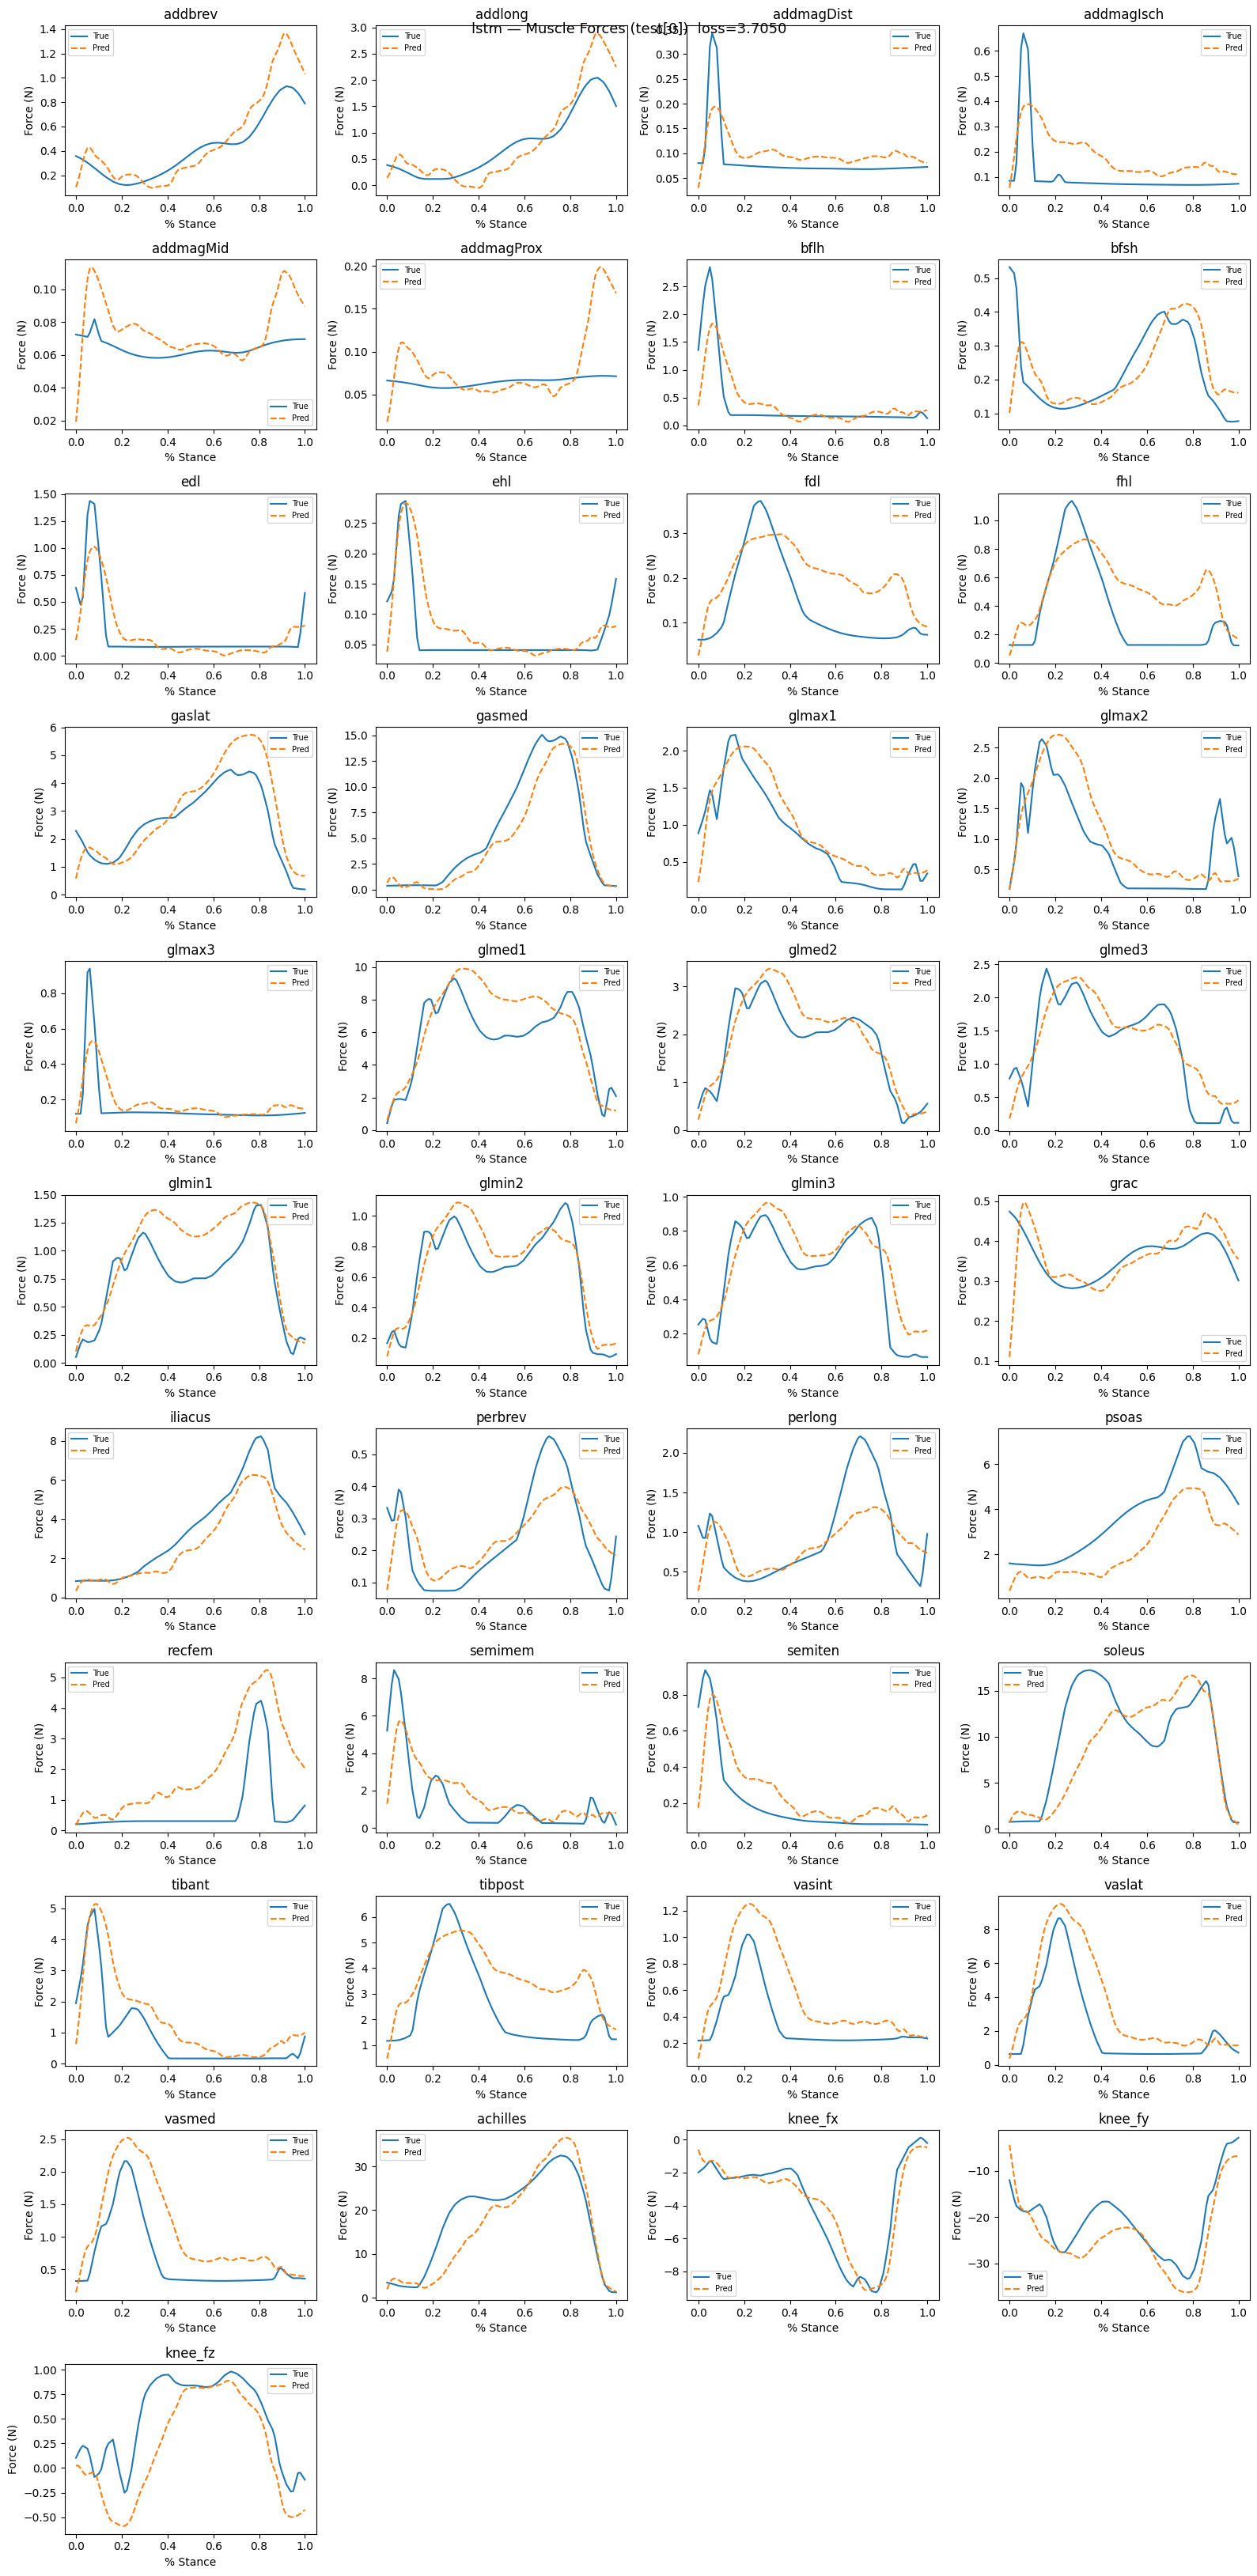

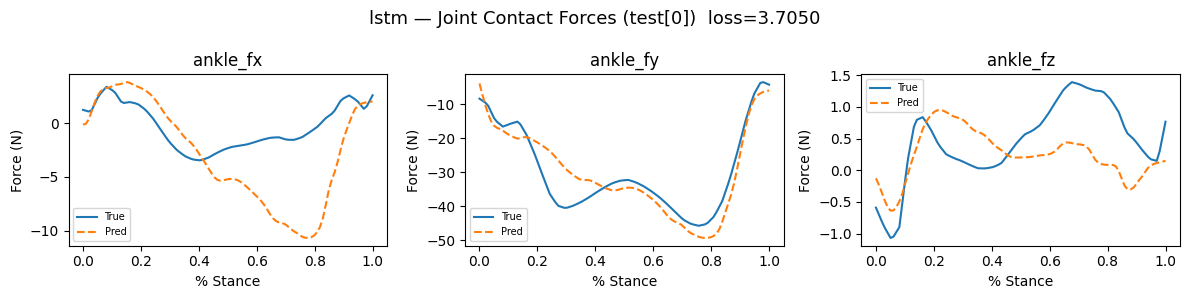

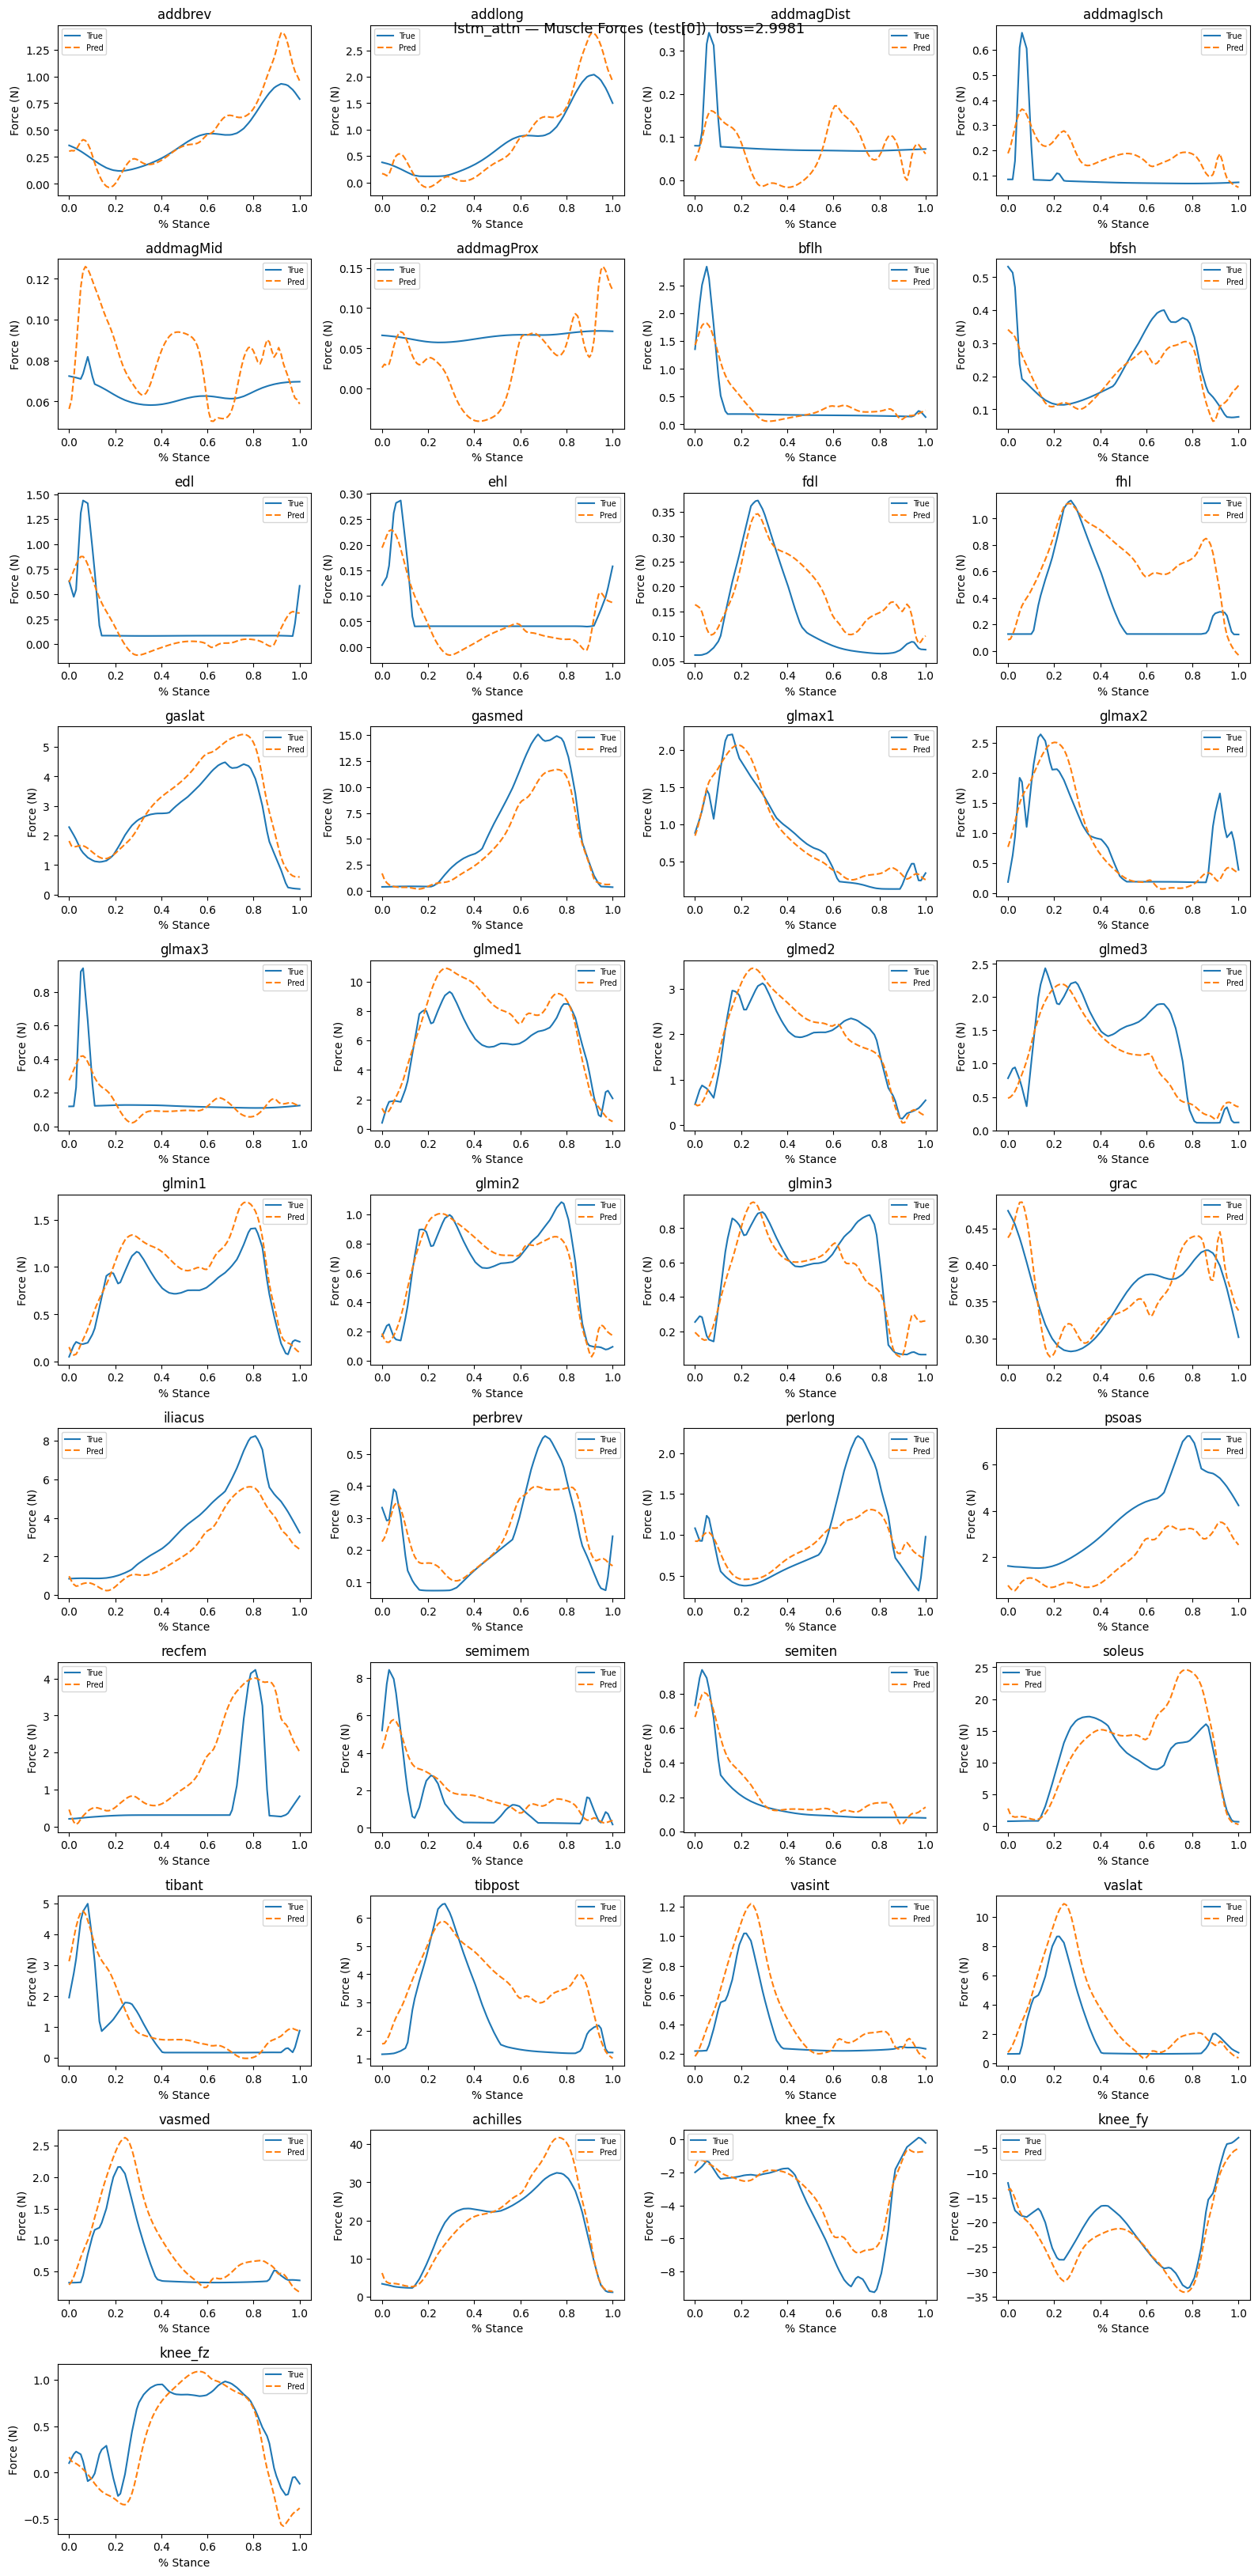

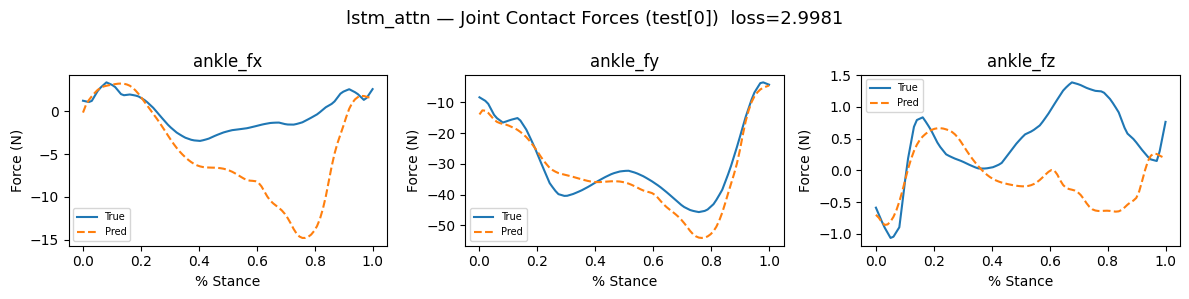

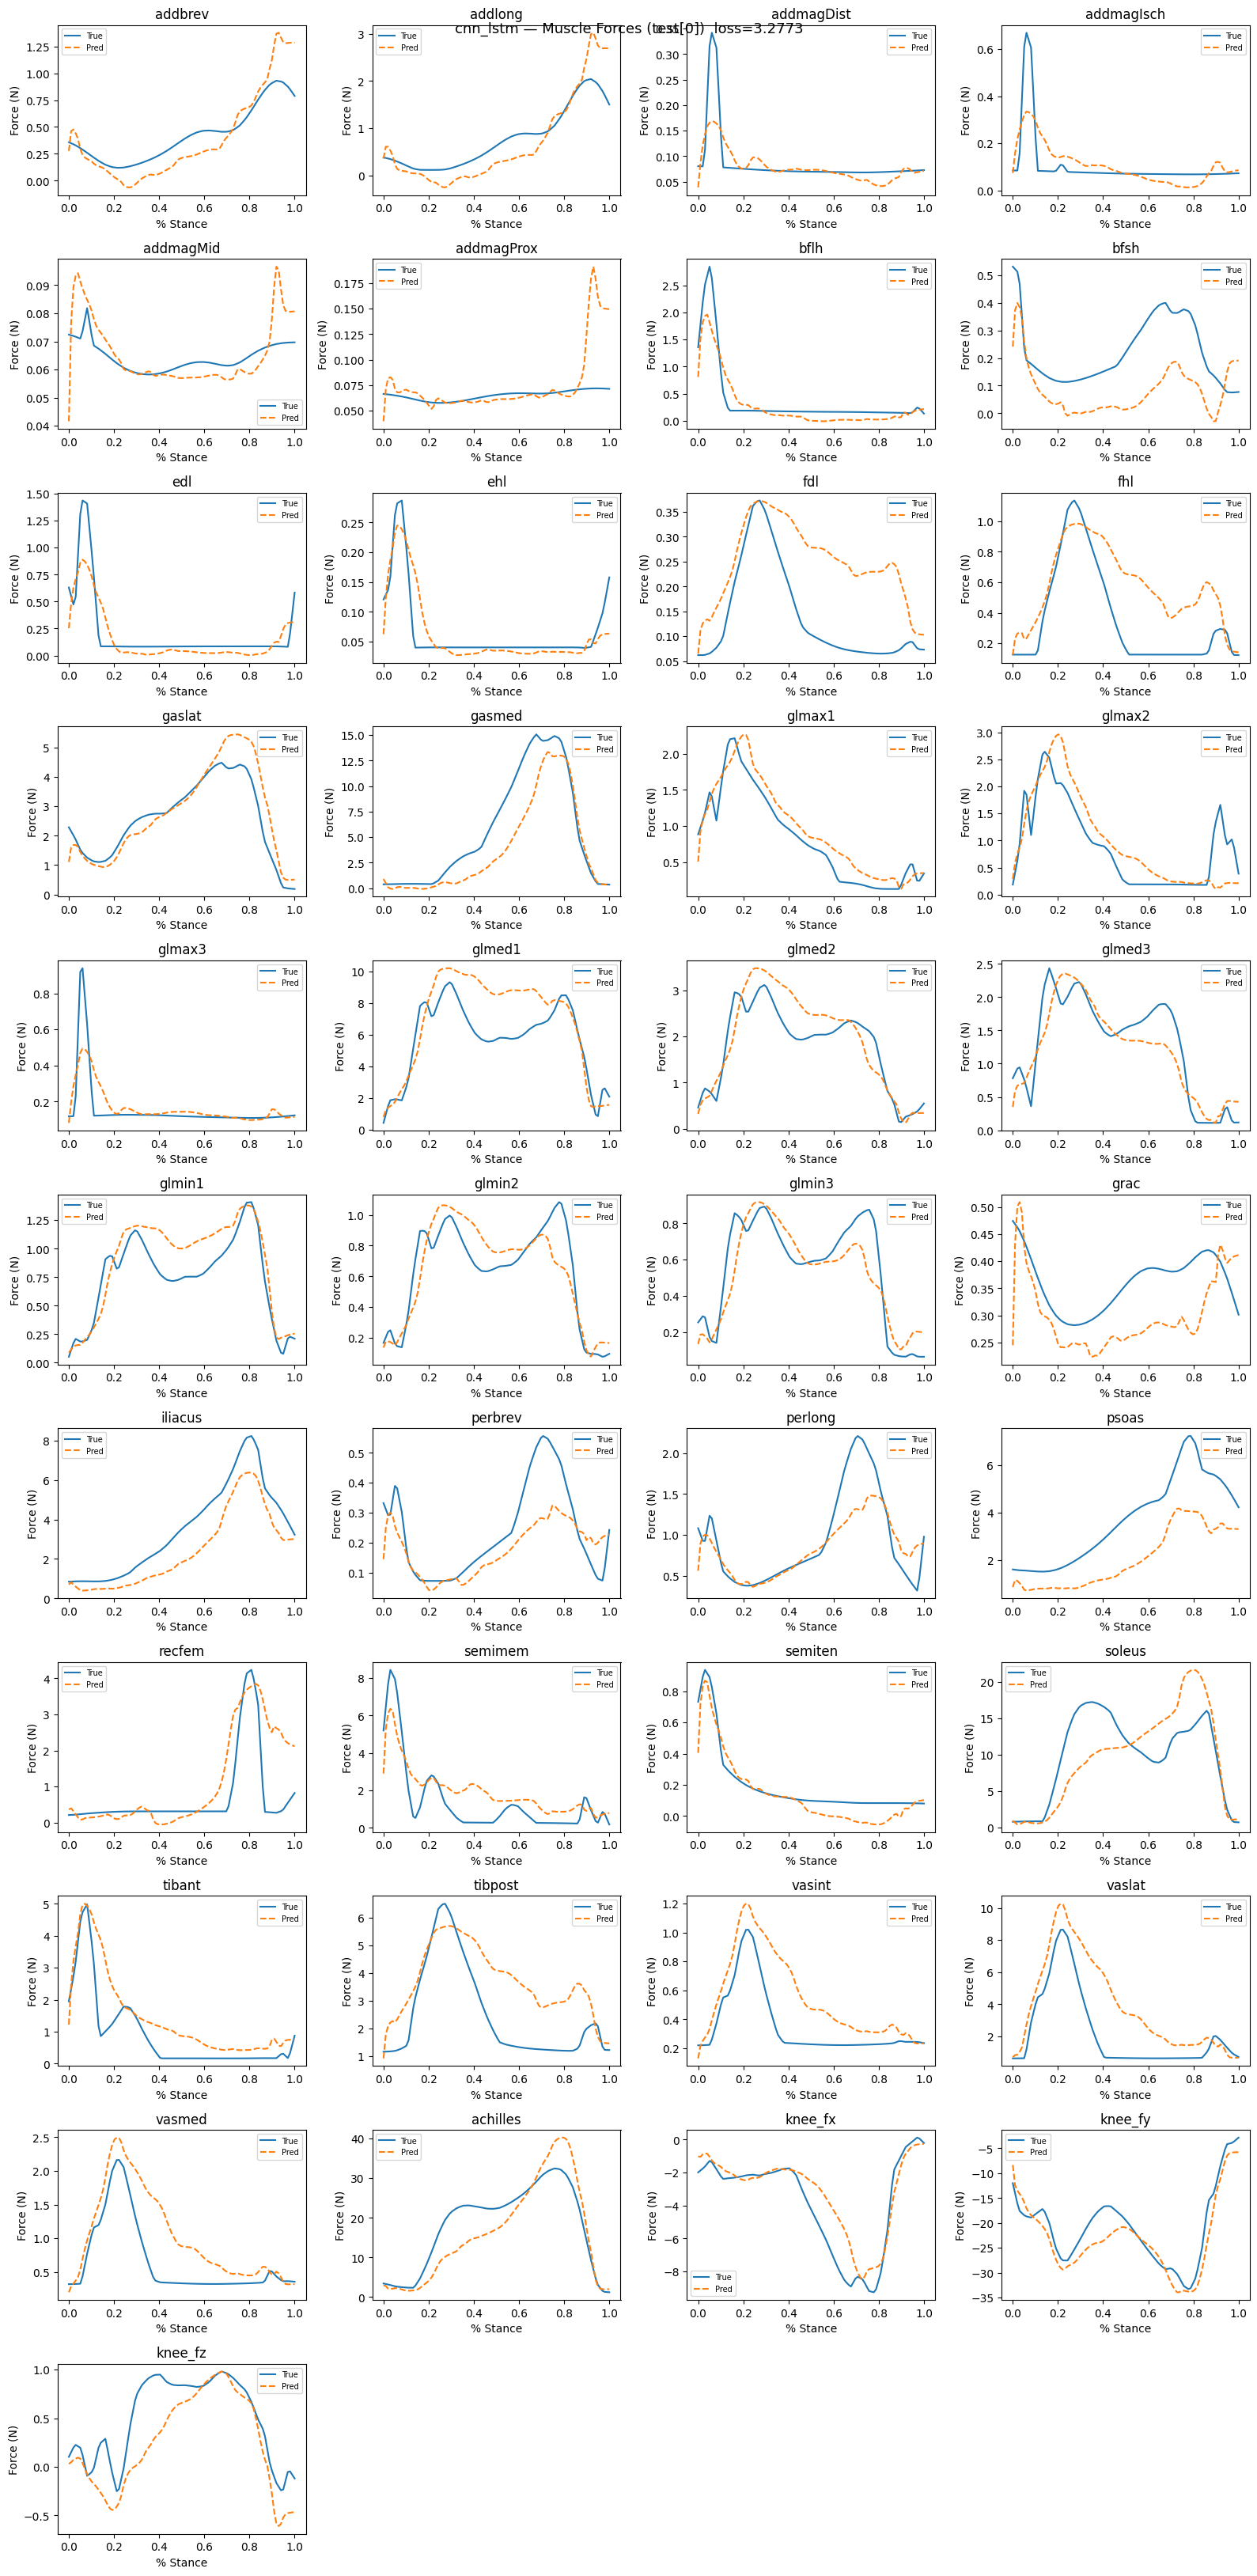

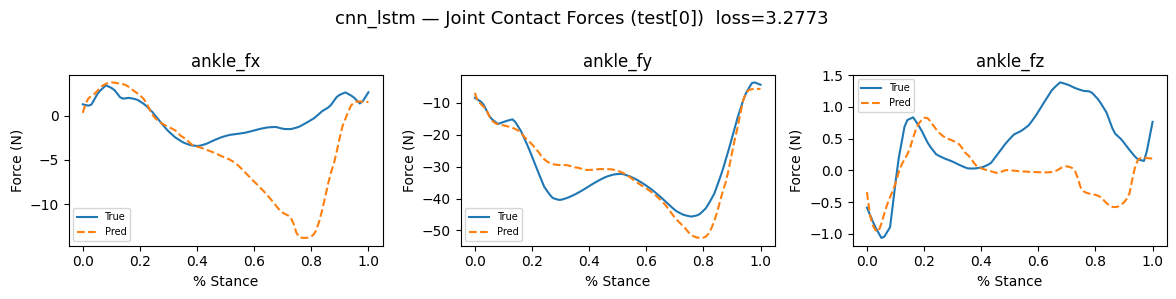

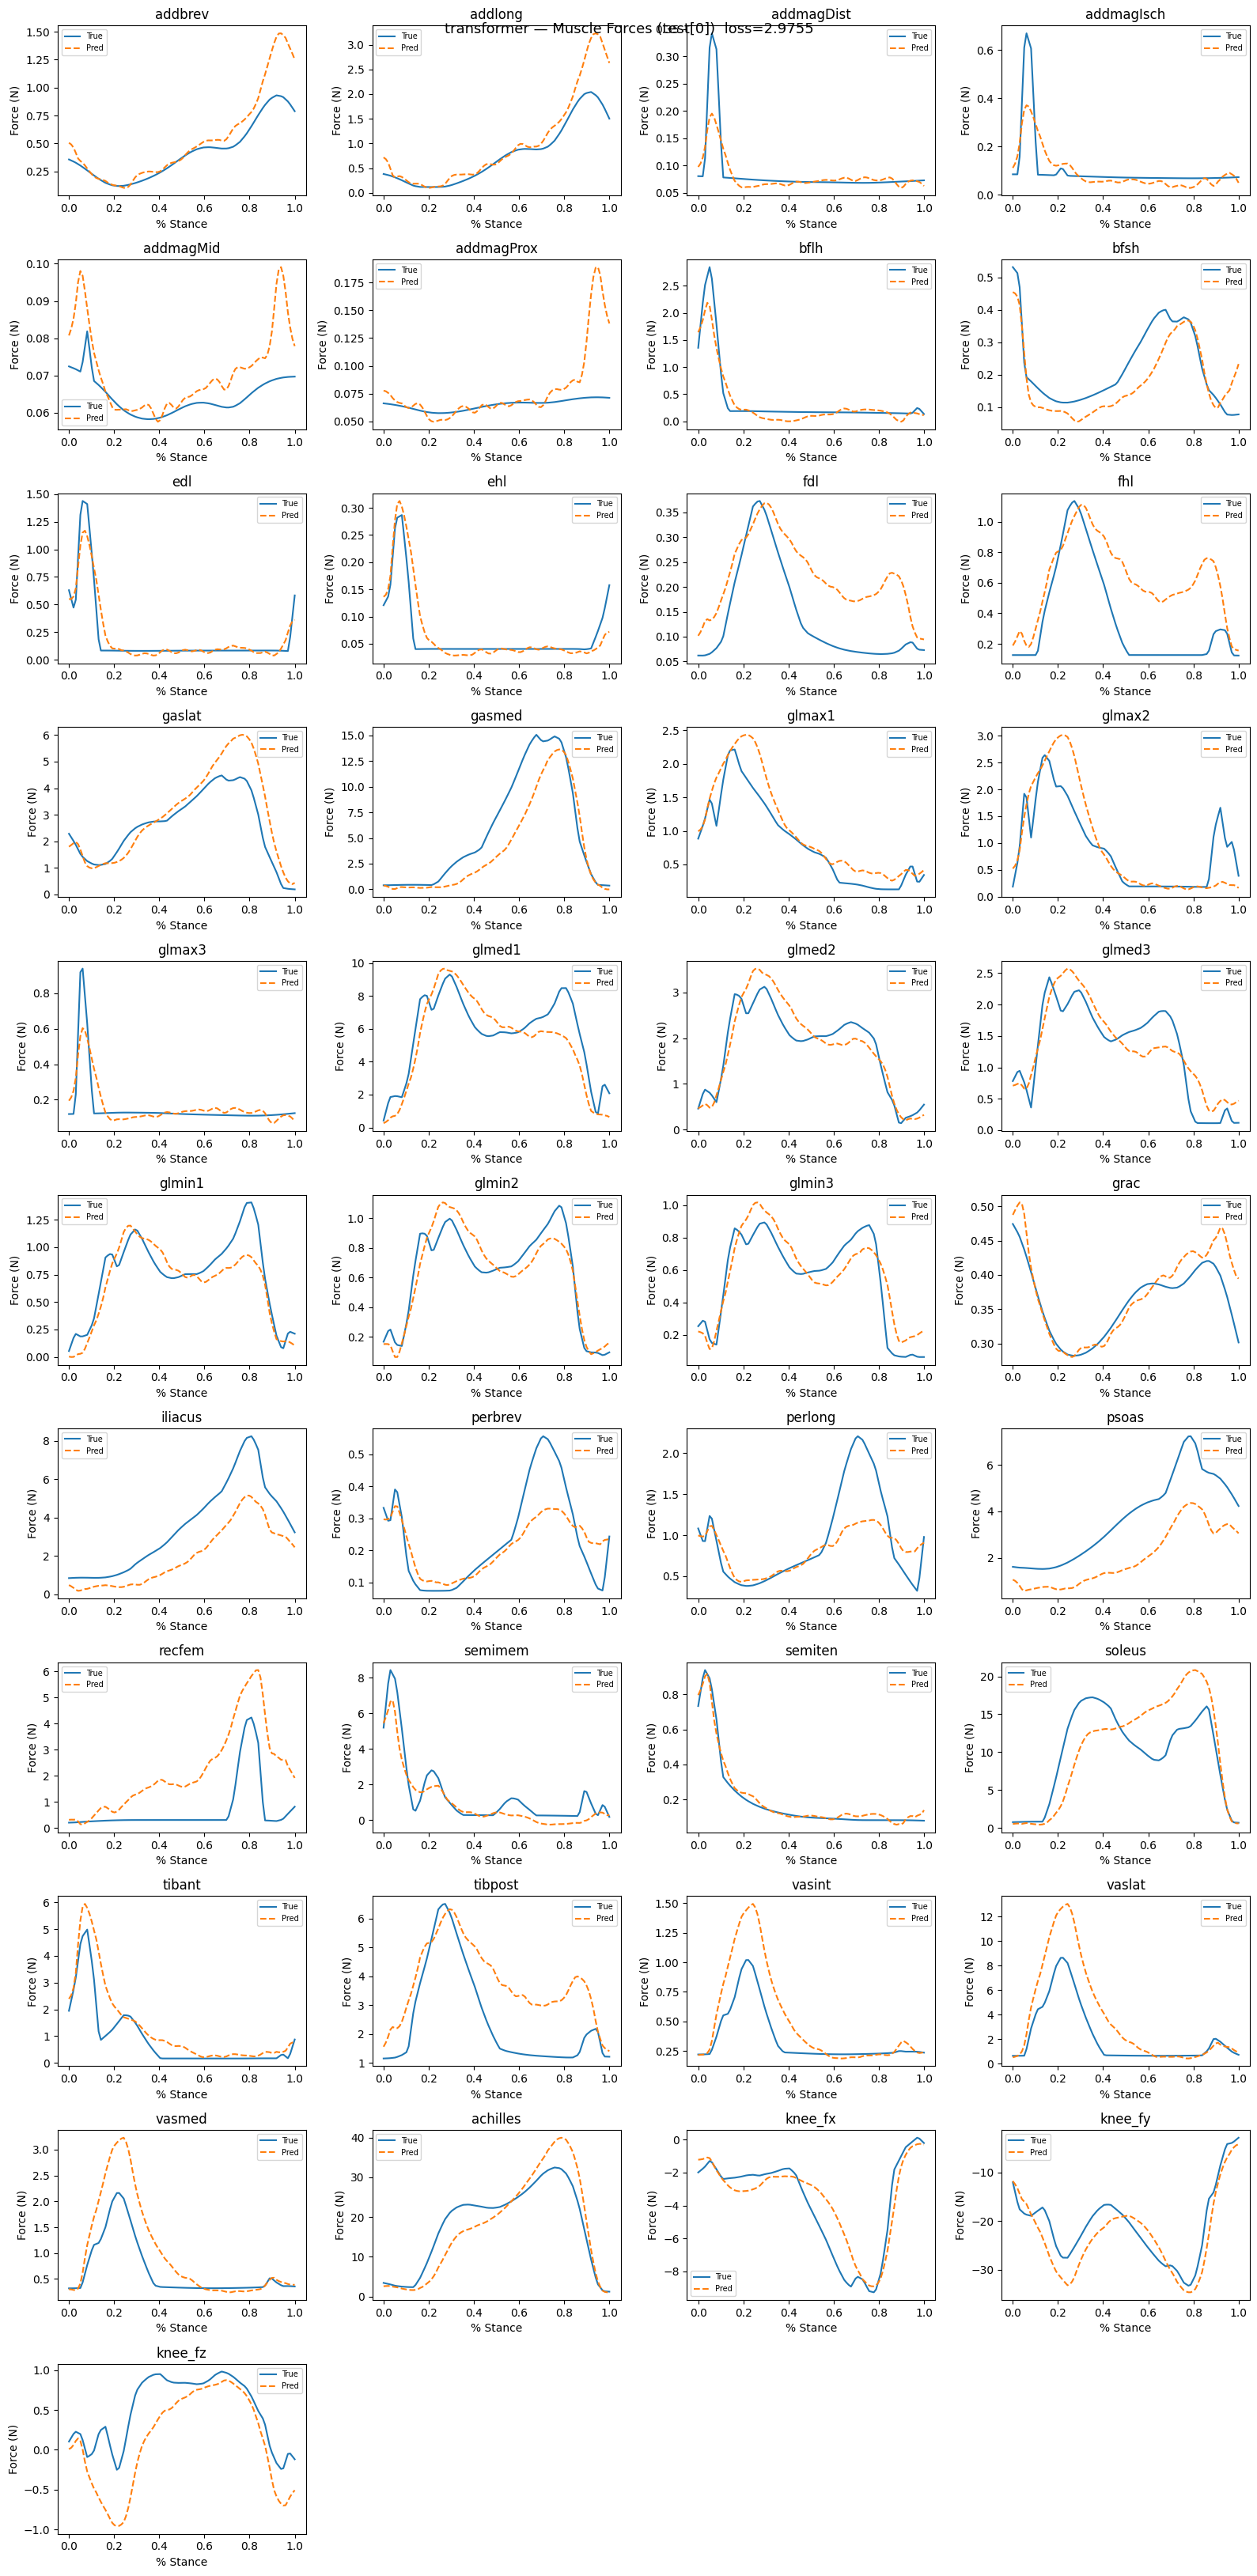

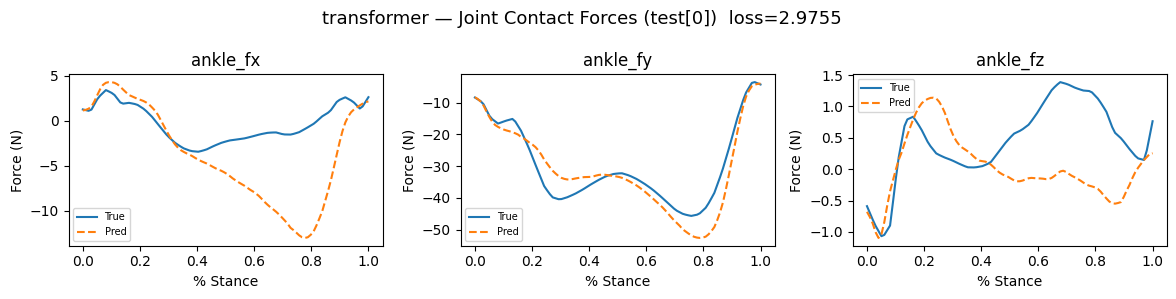

In [20]:
SAMPLE_IDX    = 0
muscle_idxs   = [OUTPUT_KEYS.index(k) for k in MUSCLE_KEYS]
joint_idxs    = [OUTPUT_KEYS.index(k) for k in JOINT_KEYS]
true_np       = y_test_t[SAMPLE_IDX].cpu().numpy()

for model_name, r in test_results.items():
    pred_np = r['preds'][SAMPLE_IDX].cpu().numpy()

    # ── muscles ──
    ncols = 4
    nrows = math.ceil(len(muscle_idxs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = axes.flatten()
    for j, idx in enumerate(muscle_idxs):
        axes[j].plot(perc_stance, true_np[:, idx], label='True')
        axes[j].plot(perc_stance, pred_np[:, idx], label='Pred', linestyle='dashed')
        axes[j].set_title(OUTPUT_KEYS[idx])
        axes[j].set_xlabel('% Stance')
        axes[j].set_ylabel('Force (N)')
        axes[j].legend(fontsize=7)
    for j in range(len(muscle_idxs), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'{model_name} — Muscle Forces (test[{SAMPLE_IDX}])  loss={r["test_loss"]:.4f}', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── joint contact forces ──
    ncols = 3
    nrows = math.ceil(len(joint_idxs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = axes.flatten()
    for j, idx in enumerate(joint_idxs):
        axes[j].plot(perc_stance, true_np[:, idx], label='True')
        axes[j].plot(perc_stance, pred_np[:, idx], label='Pred', linestyle='dashed')
        axes[j].set_title(OUTPUT_KEYS[idx])
        axes[j].set_xlabel('% Stance')
        axes[j].set_ylabel('Force (N)')
        axes[j].legend(fontsize=7)
    for j in range(len(joint_idxs), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'{model_name} — Joint Contact Forces (test[{SAMPLE_IDX}])  loss={r["test_loss"]:.4f}', fontsize=13)
    plt.tight_layout()
    plt.show()